## Mount Google Drive

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import os

project_path = "/content/drive/MyDrive/Stock_Prediction_Project"

if not os.path.exists(project_path):
    os.makedirs(project_path)

print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/Stock_Prediction_Project


# 1: Data Collection & Initial Setup

## 1.1 Install Required Libraries

In [66]:
# !pip install yfinance PyWavelets tensorflow scikit-learn matplotlib pandas --quiet

## 1.2 Import Libraries

In [67]:
import numpy as np
import pandas as pd
import yfinance as yf
import pywt
import math
import random
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Conv1D, MaxPooling1D,
    Flatten, Add, Activation, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## 1.3 Set Random Seed

In [68]:
np.random.seed(42)
tf.random.set_seed(42)

## 1.4 Download Stock Data

In [69]:
df = yf.download("AAPL", start="2010-01-01", end="2026-6-30").dropna()
df = df[["Open", "High", "Low", "Close"]]

/tmp/ipykernel_475/2412964302.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2010-01-01", end="2026-6-30").dropna()
[*********************100%***********************]  1 of 1 completed


## 1.5 Save Dataset to Drive

In [70]:
# df.to_csv(f"{project_path}/nifty50_raw.csv")

## 1.6 Keep RAW Copy

In [71]:
df_raw = df.copy()

## 1.7 Preview Data

In [72]:
print(df.tail())
print("Shape:", df.shape)

Price             Open        High         Low       Close
Ticker            AAPL        AAPL        AAPL        AAPL
Date                                                      
2026-06-23  297.540009  301.640015  294.179993  294.299988
2026-06-24  295.359985  299.700012  292.940002  293.079987
2026-06-25  287.399994  288.799988  273.750000  275.149994
2026-06-26  275.000000  285.950012  274.209991  283.779999
2026-06-29  286.730011  288.369995  279.850006  281.739990
Shape: (4146, 4)


# 2. Wavelet Denoising (Coif3)

## 2.1 Define Wavelet Denoising Function

In [73]:
def wavelet_denoise_series(x, wavelet="coif3", level=1):
    w = pywt.Wavelet(wavelet)
    coeffs = pywt.wavedec(x, w, level=level)

    detail = coeffs[1]

    sigma = np.median(np.abs(detail)) / 0.6745
    thr = sigma * np.sqrt(2 * np.log(len(x)))

    new_coeffs = [coeffs[0]]
    for c in coeffs[1:]:
        new_coeffs.append(pywt.threshold(c, thr, mode="soft"))

    xd = pywt.waverec(new_coeffs, w)
    return xd[:len(x)]

## 2.2 Apply Denoising to Dataset

In [74]:
df_denoised = df.copy()

for col in df.columns:
    df_denoised[col] = wavelet_denoise_series(df[col].values)

## 2.3 Save Denoised Data to Google Drive

In [75]:
df_denoised.to_csv(f"{project_path}/nifty50_denoised.csv")

## 2.4 Compare Raw vs Denoised

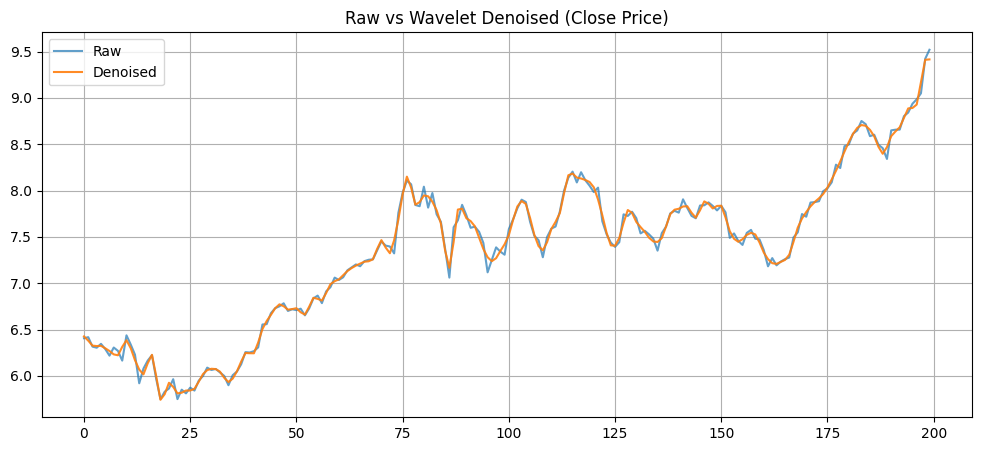

In [76]:
plt.figure(figsize=(12,5))

plt.plot(df_raw["Close"].values[:200], label="Raw", alpha=0.7)
plt.plot(df_denoised["Close"].values[:200], label="Denoised", alpha=0.9)

plt.title("Raw vs Wavelet Denoised (Close Price)")
plt.legend()
plt.grid(True)
plt.show()

# 3. Feature Scaling + Target Preparation

## 3.1 Define Columns

In [77]:
feature_cols = ["Open", "High", "Low", "Close"]
target_col   = "Close"

## 3.2 Scale DENOISED Data

In [78]:
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

X_features = feature_scaler.fit_transform(df_denoised[feature_cols])
y_target   = target_scaler.fit_transform(df_denoised[[target_col]])

## 3.3 Scale RAW Data

In [79]:
feature_scaler_raw = MinMaxScaler()
target_scaler_raw  = MinMaxScaler()

X_features_raw = feature_scaler_raw.fit_transform(df_raw[feature_cols])
y_target_raw   = target_scaler_raw.fit_transform(df_raw[[target_col]])

## 3.4 Check Shapes

In [80]:
print("DENOISED X:", X_features.shape)
print("DENOISED y:", y_target.shape)

print("RAW X:", X_features_raw.shape)
print("RAW y:", y_target_raw.shape)

DENOISED X: (4146, 4)
DENOISED y: (4146, 1)
RAW X: (4146, 4)
RAW y: (4146, 1)


## 3.5 Check Scaling Range

In [81]:
print("Min (Denoised):", X_features.min(), "Max:", X_features.max())
print("Min (Raw):", X_features_raw.min(), "Max:", X_features_raw.max())

Min (Denoised): 0.0 Max: 1.0
Min (Raw): 0.0 Max: 1.0


# 4. Create Sliding Windows (Time-Series Sequences)

## 4.1 Define Window Size

In [82]:
WINDOW = 40

## 4.2 Create Window Function

In [83]:
def create_windows(X, y, window):
    Xs, ys = [], []

    for i in range(window, len(X)):
        Xs.append(X[i-window:i])  # past 'window' days
        ys.append(y[i])           # next day value

    return np.array(Xs), np.array(ys)

## 4.3 Apply on DENOISED Data

In [84]:
X_all, y_all = create_windows(X_features, y_target, WINDOW)

## 4.4 Apply on RAW Data

In [85]:
X_all_raw, y_all_raw = create_windows(X_features_raw, y_target_raw, WINDOW)

## 4.5 Check Shapes

In [86]:
print("DENOISED X:", X_all.shape)
print("DENOISED y:", y_all.shape)

print("RAW X:", X_all_raw.shape)
print("RAW y:", y_all_raw.shape)

DENOISED X: (4106, 40, 4)
DENOISED y: (4106, 1)
RAW X: (4106, 40, 4)
RAW y: (4106, 1)


In [87]:
print("One sample input shape:", X_all[0].shape)
print("One target:", y_all[0])

One sample input shape: (40, 4)
One target: [0.00162686]


# 5. Prepare Full Training Data (No Train / Validation / Test Split)

**Note:** This notebook trains on the **entire available dataset** — there is no held-out validation or test split. All metrics computed later (RMSE, MAE, R², plots, etc.) are **in-sample**: they are computed on the same data the models were trained on, so they show how well each model fit the training data, not how it would perform on unseen future data. Treat them as a sanity check on training quality only.

## 5.1 Use the Full Dataset (No Splitting)

In [88]:
n = len(X_all)
print("Total samples available for training:", n)

Total samples available for training: 4106


## 5.2 Full DENOISED Data (used entirely for training)

In [89]:
X_train = X_all
y_train = y_all

## 5.3 Full RAW Data (used entirely for training)

In [90]:
X_train_raw = X_all_raw
y_train_raw = y_all_raw

## 5.4 Check Shapes

In [91]:
print("DENOISED:")
print(X_train.shape)

print("\nRAW:")
print(X_train_raw.shape)

DENOISED:
(4106, 40, 4)

RAW:
(4106, 40, 4)


## 5.5 Sanity Check

In [92]:
print("Total samples used for training:", n)

Total samples used for training: 4106


In [93]:
print("RAW Close sample:", df_raw["Close"].values[:5])
print("DENOISED Close sample:", df_denoised["Close"].values[:5])

RAW Close sample: [[6.40648127]
 [6.41755724]
 [6.31547594]
 [6.30380106]
 [6.34570932]]
DENOISED Close sample: [[6.42570043]
 [6.38005644]
 [6.32620878]
 [6.32169907]
 [6.32432582]]


# 6. Build LSTM Model

## 6.1 Define LSTM Model

In [94]:
def build_lstm(input_shape):
    inp = Input(shape=input_shape)

    x = LSTM(64, activation="tanh", return_sequences=True)(inp)
    x = Dropout(0.1)(x)

    x = LSTM(64, activation="tanh")(x)
    x = Dropout(0.1)(x)

    x = Dense(32, activation="tanh")(x)
    out = Dense(1)(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="mse"
    )

    return model

## 6.2 Build Model Instance

In [95]:
lstm = build_lstm((WINDOW, 4))

## 6.3 Model Summary

In [96]:
lstm.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 40, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 40, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,801 (206.25 KB)

 Trainable params: 52,801 (206.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6.4 Define Early Stopping

(Monitors training loss since no validation set is held out.)

In [97]:
cb = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

# 7. Train LSTM (RAW vs DENOISED)

## 7.1 Create Separate Models

In [98]:
lstm_raw = build_lstm((WINDOW, 4))
lstm     = build_lstm((WINDOW, 4))

## 7.2 Train on RAW Data

In [99]:
print("\nTraining LSTM on RAW data (full dataset)...")

lstm_raw.fit(
    X_train_raw, y_train_raw,
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training LSTM on RAW data (full dataset)...
Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0123
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.5283e-04
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1840e-04
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9528e-04
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.0905e-04
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.6454e-04
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.9257e-04
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.3517e-04
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.1560e-04
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.2969e-04
Epoch 13/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.4834e-04
Epoch 14/100
129/129 ━━━

## 7.3 Train on DENOISED Data

In [100]:
print("\nTraining LSTM on DENOISED data (full dataset)...")

lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training LSTM on DENOISED data (full dataset)...
Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0268
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0020
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.9206e-04
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.5274e-04
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.1313e-04
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6797e-04
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.8326e-04


## 7.4 Generate In-Sample Predictions (for reporting only — model was trained on all data)

In [101]:
# RAW predictions (in-sample)
lstm_pred_raw = lstm_raw.predict(X_train_raw)

# DENOISED predictions (in-sample)
lstm_pred = lstm.predict(X_train)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


## 7.5 Store Ground Truth (full dataset)

In [102]:
y_true_raw = y_train_raw
y_true     = y_train

## 7.6 Evaluation Function

In [103]:
def evaluate(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n=== {model_name} ===")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

## 7.7 Evaluate LSTM

In [104]:
evaluate("LSTM RAW", y_true_raw, lstm_pred_raw)
evaluate("LSTM DENOISED", y_true, lstm_pred)


=== LSTM RAW ===
MSE : 0.0001447272281551208
RMSE: 0.012030263012715923
MAE : 0.007061843517927053
R²  : 0.9978842151642608

=== LSTM DENOISED ===
MSE : 0.0005431488209550004
RMSE: 0.023305553435930253
MAE : 0.01427756452147283
R²  : 0.9921065746098116


# 8. Build & Train CNN Model

## 8.1 Define CNN Model

In [105]:
def build_cnn(input_shape):
    inp = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=2, activation="relu", padding="causal")(inp)
    x = Conv1D(64, kernel_size=2, activation="relu", padding="causal")(x)

    x = MaxPooling1D(pool_size=2)(x)
    x = Flatten()(x)

    x = Dense(64, activation="relu")(x)
    out = Dense(1)(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

## 8.2 Create Model Instances

In [106]:
cnn_raw = build_cnn((WINDOW, 4))
cnn     = build_cnn((WINDOW, 4))

## 8.3 Train on RAW Data

In [107]:
print("\nTraining CNN on RAW data (full dataset)...")

cnn_raw.fit(
    X_train_raw, y_train_raw,
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training CNN on RAW data (full dataset)...
Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0036
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0642e-04
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.2051e-04
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6349e-04
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2148e-04
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0100e-04
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9513e-04
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8289e-04
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7169e-04
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6569e-04
Epoch 11/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4506e-04
Epoch 12/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4390e-04
Epoch 13/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3980e-04
Epoch 14/100
129/129

## 8.4 Train on DENOISED Data

In [108]:
print("\nTraining CNN on DENOISED data (full dataset)...")

cnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training CNN on DENOISED data (full dataset)...
Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0031
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0172e-04
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7178e-04
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1875e-04
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0887e-04
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0465e-04
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9836e-04
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9307e-04
Epoch 9/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8285e-04
Epoch 10/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2286e-04


## 8.5 In-Sample Predictions

In [109]:
cnn_pred_raw = cnn_raw.predict(X_train_raw)
cnn_pred     = cnn.predict(X_train)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


## 8.6 Evaluate CNN

In [110]:
evaluate("CNN RAW", y_true_raw, cnn_pred_raw)
evaluate("CNN DENOISED", y_true, cnn_pred)


=== CNN RAW ===
MSE : 6.47663122986559e-05
RMSE: 0.008047752002805249
MAE : 0.004878622186041055
R²  : 0.9990531734548155

=== CNN DENOISED ===
MSE : 0.0004643283414810441
RMSE: 0.021548279316016026
MAE : 0.013068869126483596
R²  : 0.9932520499380146


# 9. Ensemble (Stacking Model)

## 9.1 Create Meta Features

In [111]:
X_meta_train = np.hstack([
    lstm_raw.predict(X_train_raw),   # LSTM (RAW)
    cnn.predict(X_train)             # CNN (DENOISED)
])


129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


## 9.2 Meta Features for Reporting (same as training features — no held-out test set)

In [112]:
# No separate test set: reuse the same in-sample meta features
X_meta_test = X_meta_train

## 9.3 Train Meta Model (Linear Regression)

In [113]:
meta = LinearRegression()
meta.fit(X_meta_train, y_train)

LinearRegression()

## 9.4 Prediction

In [114]:
ensemble_pred = meta.predict(X_meta_test).reshape(-1, 1)

## 9.5 Evaluate Ensemble

In [115]:
evaluate("Ensemble", y_true, ensemble_pred)


=== Ensemble ===
MSE : 0.0001317674208849959
RMSE: 0.011478999123834618
MAE : 0.006502277788855465
R²  : 0.9980850620207837


## 9.6 Check Model Weights

In [116]:
print("\n===== Ensemble Weights =====")
print(f"LSTM (RAW) weight : {meta.coef_[0][0]:.6f}")
print(f"CNN (DENOISED)   : {meta.coef_[0][1]:.6f}")
print(f"Bias             : {meta.intercept_[0]:.6f}")



===== Ensemble Weights =====
LSTM (RAW) weight : 1.098908
CNN (DENOISED)   : -0.085711
Bias             : -0.001469


# 10. Visualization + Final Comparison

## 10.1 Store Model Names

In [117]:
models = ["LSTM (RAW)", "CNN (DENOISED)", "Ensemble"]


## 10.2 Compute Metrics for All Models

In [118]:
def compute_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

In [119]:
metrics = {"MSE": [], "RMSE": [], "MAE": [], "R2": []}

preds = [
    lstm_pred_raw,   # LSTM (RAW)
    cnn_pred,        # CNN (DENOISED)
    ensemble_pred    # Ensemble
]

for p in preds:
    m = compute_metrics(y_true, p)
    for (k, v) in zip(metrics.keys(), m):
        metrics[k].append(v)


## 10.3 Bar Graph Comparison

In [120]:
def plot_compare(metric_name):
    values = metrics[metric_name]

    x = np.arange(len(models))

    plt.figure(figsize=(8,5))
    plt.bar(x, values)

    plt.title(f"{metric_name} Comparison Across Models", fontsize=14)
    plt.xlabel("Models")
    plt.ylabel(metric_name)
    plt.xticks(x, models)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Value labels
    for i, v in enumerate(values):
        plt.text(i, v + (v * 0.05 + 1e-6), f"{v:.4f}", ha='center')

    plt.show()

## 10.4 Plot All Metrics

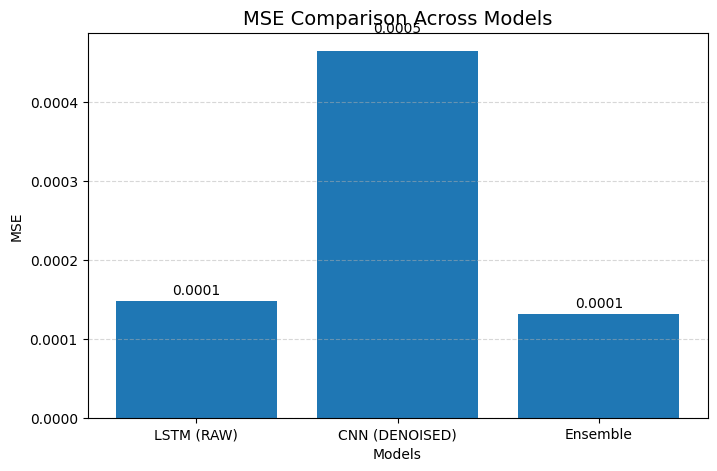

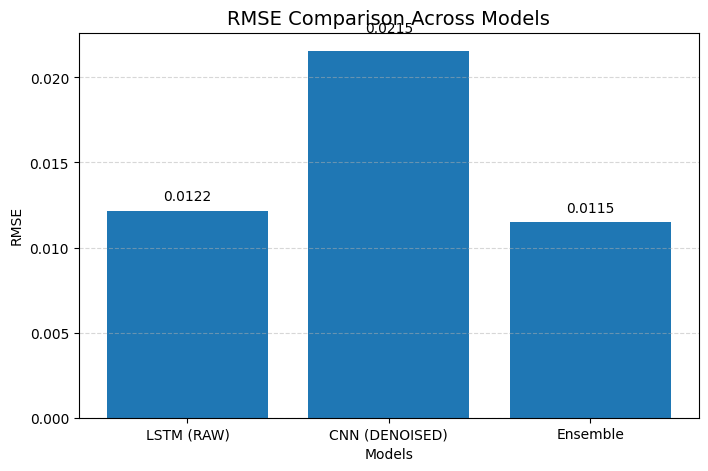

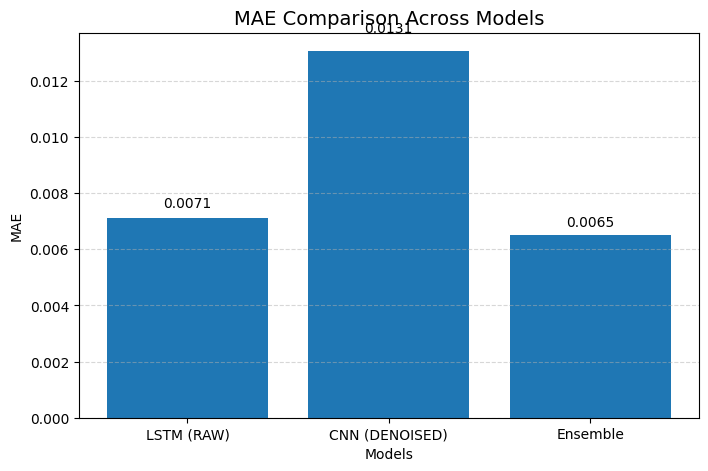

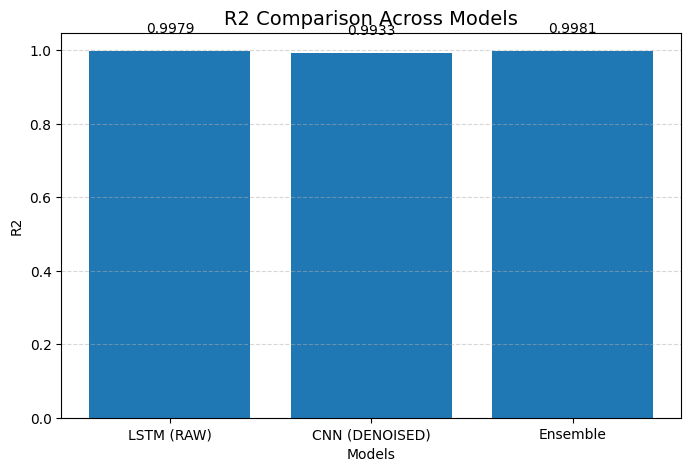

In [121]:
plot_compare("MSE")
plot_compare("RMSE")
plot_compare("MAE")
plot_compare("R2")

## 10.4 Actual vs Predicted Plot

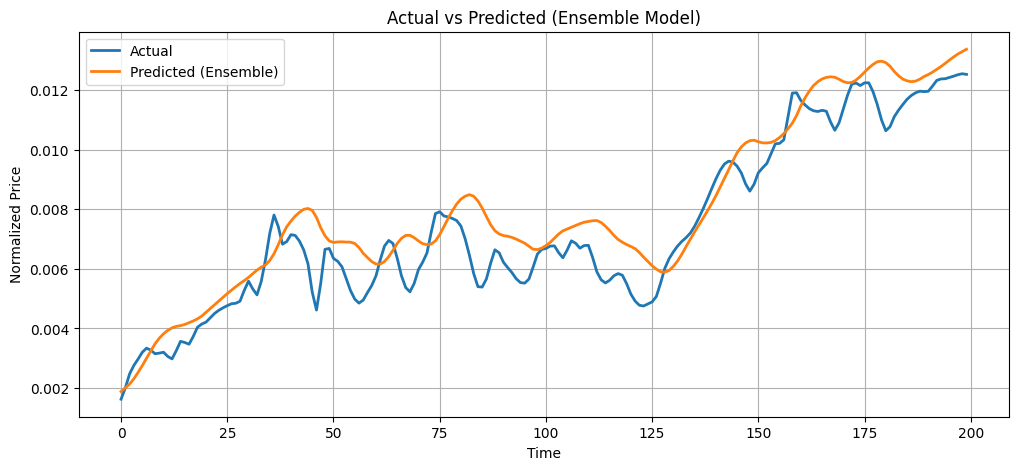

In [122]:
plt.figure(figsize=(12,5))

plt.plot(y_true[:200], label="Actual", linewidth=2)
plt.plot(ensemble_pred[:200], label="Predicted (Ensemble)", linewidth=2)

plt.title("Actual vs Predicted (Ensemble Model)")
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)

plt.show()

## 10.5 Save Predictions

In [123]:
results_df = pd.DataFrame({
    "Actual": y_true.flatten(),
    "LSTM_RAW": lstm_pred_raw.flatten(),
    "CNN_DENOISED": cnn_pred.flatten(),
    "Ensemble": ensemble_pred.flatten()
})

results_df.to_csv(f"{project_path}/predictions.csv", index=False)


## 10.6 Save Models

In [124]:
import joblib

lstm_raw.save(f"{project_path}/lstm_model.keras")
cnn.save(f"{project_path}/cnn_model.keras")
joblib.dump(meta, f"{project_path}/meta_model.pkl")


['/content/drive/MyDrive/Stock_Prediction_Project/meta_model.pkl']

## 10.7 Save Scalers

In [125]:
import joblib

joblib.dump(feature_scaler, f"{project_path}/feature_scaler.pkl")
joblib.dump(target_scaler, f"{project_path}/target_scaler.pkl")
joblib.dump(feature_scaler_raw, f"{project_path}/feature_scaler_raw.pkl")
joblib.dump(target_scaler_raw, f"{project_path}/target_scaler_raw.pkl")

['/content/drive/MyDrive/Stock_Prediction_Project/target_scaler.pkl']